# PRÁCTICA MACHINE LEARNING

## Graph Classification with Graph Neural Networks. Dataset: ENZYMES

Profesor: Francisco Escolano

Alumno: Nicolás Vives Vicente

La tarea más común para la clasificación de grafos es la **predicción de propiedades moleculares**, en la que las moléculas se representan como grafos, y la tarea puede consistir en inferir si una molécula inhibe la replicación del virus del VIH o no.

La Universidad Técnica de Dortmund ha recopilado una amplia gama de diferentes conjuntos de datos de clasificación de grafos, conocidos como [**TUDatasets**](https://chrsmrrs.github.io/datasets/), los cuales también son accesibles a través de [`torch_geometric.datasets.TUDataset`](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets.TUDataset) en PyTorch Geometric.

En este notebook se estudia el **conjunto de datos ENZYMES**:

## Librerías necesarias:

In [1]:
# Librerías Estándar de Python
import os
import csv
import random
from collections import Counter

# Análisis de Datos, Grafos y Visualización
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# PyTorch
import torch
import torch.nn.functional as F
from torch.nn import Linear

# PyTorch Geometric (Utilidades)
import torch_geometric.data
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx, to_dense_batch, to_dense_adj

# PyTorch Geometric (Capas GNN y Pooling)
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool  # Global Mean Pooling
from torch_geometric.nn import global_add_pool   # Global Add Pooling
from torch_geometric.nn import global_max_pool   # Global Max Pooling

# Modelo Net
from torch_geometric.nn import dense_mincut_pool, DenseGraphConv

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Inspección del dataset:

In [2]:
dataset = TUDataset(root='data/TUDataset', name='ENZYMES')

print()
print(f'Dataset: {dataset}:')
print('====================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Extraemos las etiquetas (y) de cada grafo y las contamos
labels = [data.y.item() for data in dataset]
class_counts = Counter(labels)

print('====================')
print('Samples per class:')
for cls, count in sorted(class_counts.items()):
    print(f' - Class {cls}: {count}')
print('====================')

num_nodes_list = [data.num_nodes for data in dataset]

mean_nodes = np.mean(num_nodes_list)
min_nodes = np.min(num_nodes_list)
max_nodes = np.max(num_nodes_list)

print('Node statistics per molecule:')
print(f' - Mean nodes: {mean_nodes:.2f}')
print(f' - Min nodes: {min_nodes}')
print(f' - Max nodes: {max_nodes}')
print('====================')

data = dataset[0]  # Get the first graph object.

print()
print(data)
print('=============================================================')

# Gather some statistics about the first graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')


Dataset: ENZYMES(600):
Number of graphs: 600
Number of features: 3
Number of classes: 6
Samples per class:
 - Class 0: 100
 - Class 1: 100
 - Class 2: 100
 - Class 3: 100
 - Class 4: 100
 - Class 5: 100
Node statistics per molecule:
 - Mean nodes: 32.63
 - Min nodes: 2
 - Max nodes: 126

Data(edge_index=[2, 168], x=[37, 3], y=[1])
Number of nodes: 37
Number of edges: 168
Average node degree: 4.54
Has isolated nodes: False
Has self-loops: False
Is undirected: True


El conjunto de datos `ENZYMES` destaca por su simetría. A continuación, se detallan sus características principales:

* **Número total de grafos:** 600
* **Características de nodo:** 3
* **Número de clases:** 6 (clasificación multiclase)
* **Distribución de clases:** Perfectamente equilibrada, con exactamente 100 muestras para cada una de las 6 clases (Clase 0 a Clase 5).

**Estadísticas de tamaño por molécula:**
* **Media de nodos:** 32.63
* **Rango de nodos:** De 2 (mínimo) a 126 (máximo).

Al examinar el primer objeto de grafo del conjunto (`Data(edge_index=[2, 168], x=[37, 3], y=[1])`), observamos su composición exacta:

* **Estructura básica:** 37 nodos (con vectores de características de 3 dimensiones) y 168 aristas, lo que resulta en un grado promedio de 4.54 por nodo.
* **Etiquetas:** Cuenta con exactamente una etiqueta de clasificación para el grafo completo ($y=[1]$).

Además, el análisis topológico de esta primera muestra revela propiedades estructurales clave que nos ayudan a comprender la naturaleza de los datos:

* **No dirigido (*Is undirected: True*):** Las relaciones espaciales o estructurales entre los elementos son bidireccionales.
* **Conectividad total (*Has isolated nodes: False*):** La estructura no presenta nodos aislados, asegurando que todos los elementos forman parte de la topología principal del grafo.
* **Sin bucles (*Has self-loops: False*):** No existen conexiones de un nodo consigo mismo.


Como tenemos seis clases, veamos un ejemplo de molécula perteneciente a cada una de ellas.

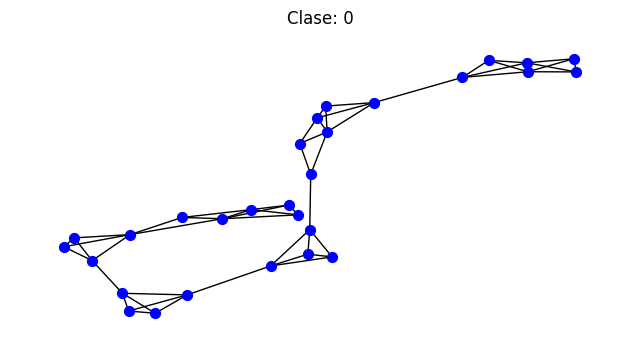

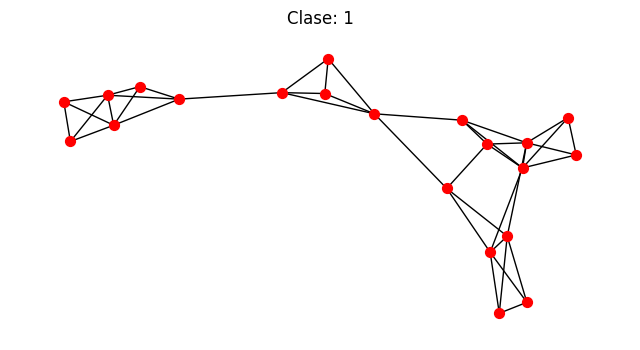

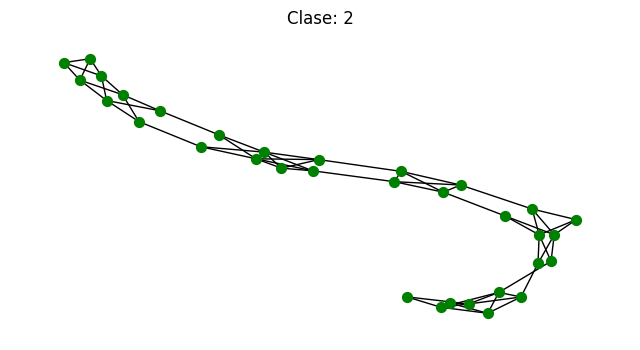

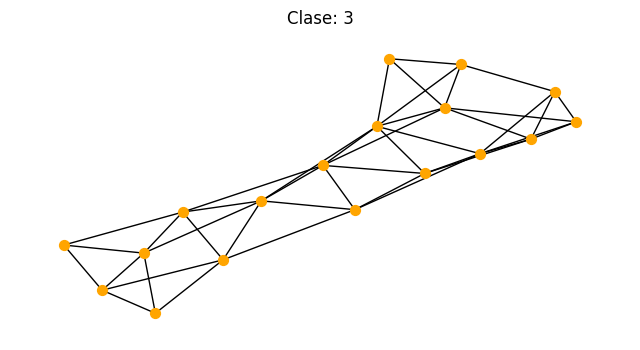

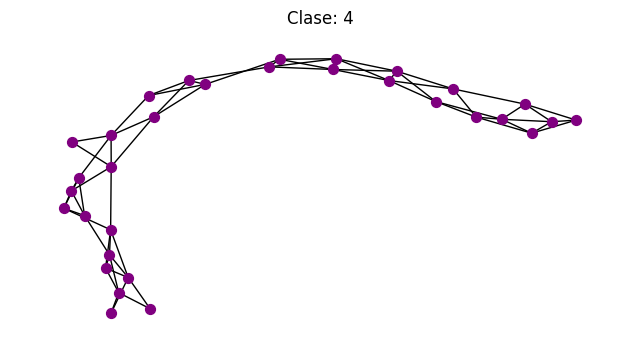

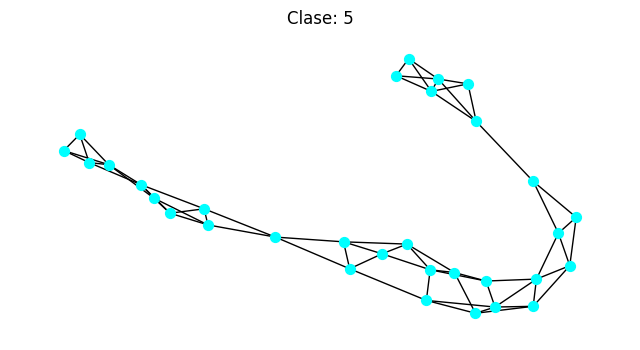

In [4]:
# Iteramos por las 6 clases (del 0 al 5)
for clase in range(6):
    grafos_clase = [t for t in dataset if t.y == clase]
    
    # Comprobamos que haya al menos un grafo de esa clase por seguridad
    if grafos_clase:
        data = random.choice(grafos_clase)
        
        g = to_networkx(data, to_undirected=True)
        
        plt.figure(figsize=(8, 4))
        plt.title(f"Clase: {clase}")
        
        nx.draw(g, node_color=['blue', 'red', 'green', 'orange', 'purple', 'cyan'][clase], node_size=50)
        plt.show()
    else:
        print(f"No se encontraron grafos para la clase {clase}")


Antes de comenzar con el entrenamiento y evaluación de los modelos conviene mencionar que se han detectado algunos problemas en el código proporcionado para la práctica y se han solucionado de las siguientes formas:

- Cálculo Aislado del Espectro Laplaciano (Graph-by-Graph):

    - Problema: Calcular el Laplaciano sobre el batch completo genera un grafo enorme, con tantas componentes desconectadas como moléculas haya en el lote. Matemáticamente, esto produce un autovalor igual a cero por cada componente. Al seleccionar los $k$ primeros, estos ceros acaparan la selección, entregando a la red autovectores vacíos que hacen inútil la geometría espacial y disparan el coste computacional al operar sobre una matriz gigante.

    - Solución implementada: Se ha aplicado una estrategia de "divide y vencerás", modificando la función para que desempaquete el lote y calcule el Laplaciano molécula por molécula de forma estrictamente individual. Esto garantiza un único autovalor cero por grafo, permitiendo que el resto de los $k$ autovectores extraigan correctamente las auténticas frecuencias estructurales y formas tridimensionales, reduciendo además la complejidad computacional.

- Corrección del Bucle de Validación (DataLoaders y Reproducibilidad):

    - Problema: La evaluación de modelos (incluyendo la red base Net) estaba consumiendo DataLoaders instanciados globalmente al inicio del notebook. Esto provocaba que, aunque los modelos variaran sus pesos iniciales y por tanto sí daban resultados distintos, no se estaba respetando la semilla de reproducibilidad para la partición de datos en las distintas iteraciones.

    - Solución implementada: Se ha reestructurado el bucle principal de evaluación. Ahora, la división del dataset y la generación de los train_loader y test_loader se ejecutan internamente en cada iteración, garantizando que los datos de entrenamiento y prueba cambien respetando la partición de los datos según la semilla activa.

Funciones heredadas con las modificaciones aplicadas:

In [3]:
def compute_laplacian_eigenvectors_pytorch(data, k):
    # 1. Convert PyTorch Geometric graph to NetworkX graph
    g = to_networkx(data, to_undirected=True)

    # 2. Compute the normalized Laplacian matrix using NetworkX
    # networkx.normalized_laplacian_matrix returns a sparse matrix
    # Then we make it dense and compatible with numpy
    L = nx.normalized_laplacian_matrix(g).todense()

    # 3. Finding eigen values and eigen vectors
    e, evecs = np.linalg.eig(L)
    #e.shape, evecs.shape

    # 4. Sort eigenvectors
    # Sort them (both e's and evecs's) ascending
    idx =e.argsort()
    e = e[idx]
    evecs = evecs[:,idx]

    # 3. Convert the sparse Laplacian matrix to a dense PyTorch tensor
    # Convert to dense numpy array first, then to torch tensor
    evecs_torch = torch.tensor(np.real(evecs[:,:k]), dtype=torch.float32)

    return evecs_torch

# Train and test functions. Use k=0 when no spectral info
def train(model, train_loader, optimizer, k):
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    for data in train_loader:  # Iterate in batches over the training dataset.
        optimizer.zero_grad()
        # Ensure all data components are on the correct device
        data.x = data.x.to(device)
        data.edge_index = data.edge_index.to(device)
        data.y = data.y.to(device)
        data.batch = data.batch.to(device)

        # MODIFICACIÓN
        if k > 0:
            evecs_list = []
            # Desempaquetamos el batch en grafos individuales
            for single_graph in data.to_data_list():
                # Calculamos el Laplaciano molécula por molécula
                evecs_single = compute_laplacian_eigenvectors_pytorch(single_graph, k=k)
                num_evecs = evecs_single.size(1)
                if num_evecs < k:
                    columnas_faltantes = k - num_evecs
                    # Rellenamos con ceros las columnas que faltan
                    evecs_single = F.pad(evecs_single, (0, columnas_faltantes, 0, 0), "constant", 0.0)
                
                evecs_list.append(evecs_single)
            
            # Volvemos a unir los resultados en un solo tensor y lo pasamos a la GPU
            evecs_torch = torch.cat(evecs_list, dim=0).to(device)
            # Concatenamos con las características originales
            data.x = torch.cat([data.x, evecs_torch], dim=1)
        # FIN MODIFICACIÓN

        # Pass data components to the model
        out = model(data.x, data.edge_index, data.batch)

        loss = criterion(out, data.y)  # Compute the loss.
        loss.backward()  # Derive gradients.
        optimizer.step()  # Update parameters based on gradients.

        total_loss += loss.item() * data.y.size(0)
        pred = out.argmax(dim=1)
        total_correct += (pred == data.y).sum().item()
        total_samples += data.y.size(0)

    return total_loss / total_samples, total_correct / total_samples

def test(model, loader, k):
    model.eval()
    total_correct = 0
    total_samples = 0
    total_loss = 0

    with torch.no_grad():
        for data in loader:  # Iterate in batches over the training/test dataset.
            # Ensure all data components are on the correct device
            data.x = data.x.to(device)
            data.edge_index = data.edge_index.to(device)
            data.y = data.y.to(device)
            data.batch = data.batch.to(device)

        # MODIFICACIÓN
            if k > 0:
                evecs_list = []
                for single_graph in data.to_data_list():
                    evecs_single = compute_laplacian_eigenvectors_pytorch(single_graph, k=k)
                    num_evecs = evecs_single.size(1)
                    if num_evecs < k:
                        columnas_faltantes = k - num_evecs
                        # Rellenamos con ceros las columnas que faltan
                        evecs_single = F.pad(evecs_single, (0, columnas_faltantes, 0, 0), "constant", 0.0)
                    
                    evecs_list.append(evecs_single)
                
                evecs_torch = torch.cat(evecs_list, dim=0).to(device)
                data.x = torch.cat([data.x, evecs_torch], dim=1)
        # FIN MODIFICACIÓN

            out = model(data.x, data.edge_index, data.batch)

            loss = criterion(out, data.y) # Compute the loss.
            total_loss += loss.item() * data.y.size(0)

            pred = out.argmax(dim=1)  # Use the class with highest probability.
            total_correct += int((pred == data.y).sum())  # Check against ground-truth labels.
            total_samples += data.y.size(0)

    return total_loss / total_samples, total_correct / total_samples

def split(dataset, seed):
  torch.manual_seed(seed)
  dataset = dataset.shuffle()

  # Get 25% approx per test
  split_idx = int(len(dataset) * 0.75)
  print("split idx", split_idx)

  train_dataset = dataset[:split_idx]
  test_dataset = dataset[split_idx:]

  #print(f'Number of training graphs: {len(train_dataset)}')
  #print(f'Number of test graphs: {len(test_dataset)}')
  return train_dataset, test_dataset

## Experimento 1: Evaluación de Arquitecturas Base

Comenzamos el análisis del dataset **ENZYMES** estableciendo las líneas base. Al igual que en el estudio anterior, el objetivo es realizar una clasificación de las moléculas, abordando en este caso un problema multiclase con **6 categorías posibles**.

En esta fase inicial se utilizará la configuración predeterminada del *notebook* original para comprobar su comportamiento base sobre este conjunto de datos:

| Hiperparámetro | Valor |
| :--- | :--- |
| Canales Ocultos (*Hidden Channels*) | 64 |
| Número de Capas Convolucionales | 3 |
| Resolución Espectral ($k$) | 4 |
| Tipo de Agregación (*Pooling*) | Global Mean Pool |

Las redes se han adaptado específicamente a la dimensionalidad y exigencias de este nuevo problema:

1. **GCN:** Actúa como línea base. Su primera capa recibe **3 dimensiones** (las características bioquímicas de los nodos). Tras 3 capas de 64 canales, finaliza en una capa lineal que emite una predicción sobre 6 clases, ignorando completamente la topología global del grafo.
2. **GCNEig (Fusión Temprana):** Añade la codificación espectral desde el inicio. Su entrada se amplía a **7 dimensiones** (3 bioquímicas + 4 espaciales). Esto permite a la red procesar simultáneamente las características del nodo y su posición global en la estructura proteica desde el primer salto de mensaje.
3. **GCNEigDecoupled (Fusión Tardía):** Emplea vías de procesamiento paralelas. Analiza las características iniciales en la rama convolucional (entrada de 3 dimensiones) y la geometría espacial en una proyección lineal independiente (proyectando los 4 autovectores a 32 canales). Ambas señales se concatenan en la profundidad de la red antes de emitir la clasificación en las 6 salidas finales.

In [9]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=64,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=64, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=64, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(3, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=6, bias=True)
)
GCNEig(
  (conv1): GCNConv(7, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=6, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(3, 64)
  (conv2): GCNConv(64, 32)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=6, bias=True)
  (lin2): Linear(in_features=4, out_features=32, bias=True)
)


In [13]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 64
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Mean Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_ENZYMES.csv")
        with open("resultados_ENZYMES.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_ENZYMES.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCN
Random State 12345  in the iteration 0
split idx 450
Epoch: 001, Loss: 1.80104, Train Acc: 0.14889
Epoch: 002, Loss: 1.79360, Train Acc: 0.14889
Epoch: 003, Loss: 1.79805, Train Acc: 0.16000
Epoch: 004, Loss: 1.78845, Train Acc: 0.18667
Epoch: 005, Loss: 1.77173, Train Acc: 0.22667
Epoch: 006, Loss: 1.76766, Train Acc: 0.20889
Epoch: 007, Loss: 1.78473, Train Acc: 0.19778
Epoch: 008, Loss: 1.79199, Train Acc: 0.19333
Epoch: 009, Loss: 1.77074, Train Acc: 0.20889
Epoch: 010, Loss: 1.77283, Train Acc: 0.20667
Epoch: 011, Loss: 1.78557, Train Acc: 0.21333
Epoch: 012, Loss: 1.75864, Train Acc: 0.21111
Epoch: 013, Loss: 1.74583, Train Acc: 0.22889
Epoch: 014, Loss: 1.76172, Train Acc: 0.23556
Epoch: 015, Loss: 1.75655, Train Acc: 0.22000
Epoch: 016, Loss: 1.77507, Train Acc: 0.22444
Epoch: 017, Loss: 1.73675, Train Acc: 0.27333
Epoch: 018, Loss: 1.73249, Train Acc: 0.26889
Epoch: 019, Loss: 1.72718, Train Acc: 0.25111
Epoch: 020, Loss: 1.75923, Train Acc: 0.24444
Epo

Tras evaluar la configuración predeterminada, se obtuvieron las siguientes métricas de rendimiento:

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCN** | 64 | 3 | Mean | 0 | $25.49 \pm 2.18$ | $\mathbf{26.80 \pm 3.69}$ |
| **GCNEig** | 64 | 3 | Mean | 4 | $31.85 \pm 4.46$ | $25.20 \pm 3.92$ |
| **GCNEigDecoupled** | 64 | 3 | Mean | 4 | $27.51 \pm 3.06$ | $24.27 \pm 4.13$ |

* Destaca inmediatamente una caída drástica en la precisión respecto a MUTAG (donde se rondaba el 80%). ENZYMES es un problema mucho más complejo (6 clases), donde una elección  aleatoria daría un $\sim 16.6\%$ de precisión. Superar este umbral aleatorio y alcanzar un $\sim 26\%$ demuestra que los modelos están logrando extraer patrones, pero enfrentan un reto considerable.

* Sorprendentemente, el modelo `GCN` obtiene el mejor resultado en validación (**26.80%**), superando a las dos variantes que incluyen información espectral.
* El modelo `GCNEig` logra casi un 32% en entrenamiento pero cae al 25.20% en validación. Esto indica que, al utilizar `Global Mean Pool`, añadir autovectores en proteínas complejas genera ruido; la red memoriza esta geometría específica en el entrenamiento pero fracasa al generalizar con nuevos datos.

Al igual que en las etapas iniciales de MUTAG, existe la fuerte sospecha de que hacer un promedio (`Mean Pool`) de todos los nodos de una proteína destruye la información crítica de sus sitios activos locales. Esto justifica el **Experimento 2**, donde evaluaremos si alterar la función de agregación permite a la red retener estas características vitales y mejorar la detección de la clase enzimática.

## Experimento 2: Impacto de `Global Max Pool`

Tras observar el bajo rendimiento obtenido con la agregación por promedio (`Mean Pool`), en este experimento se plantea modificar la capa de salida (*readout layer*) de las redes.

La decisión de cambiar el criterio de agregación responde se deba a la estructura del dataset:

* Las macromoléculas en ENZYMES forman grafos notablemente más grandes que las pequeñas moléculas de MUTAG.
* Utilizar un promedio tiende a diluir las características locales críticas entre todos los nodos, mientras que aplicar una suma haría que el vector latente resultante dependiera excesivamente del tamaño total de la proteína.
* Se propone el uso de `Global Max Pool` para que actúe como un detector de características relevantes. En el contexto bioquímico, esta operación captura únicamente las activaciones más altas de la red. Estas señales extremas suelen corresponderse con las regiones activas de la enzima, permitiendo a la red aislar la información clave sin importar el tamaño o la cantidad de "nodos inactivos" que conformen el resto de la estructura.

In [14]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=64,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=64, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=64, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(3, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=6, bias=True)
)
GCNEig(
  (conv1): GCNConv(7, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=6, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(3, 64)
  (conv2): GCNConv(64, 32)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=6, bias=True)
  (lin2): Linear(in_features=4, out_features=32, bias=True)
)


In [ ]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 64
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Max Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_ENZYMES.csv")
        with open("resultados_ENZYMES.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_ENZYMES.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCN
Random State 12345  in the iteration 0
split idx 450
Epoch: 001, Loss: 1.80300, Train Acc: 0.17333
Epoch: 002, Loss: 1.79185, Train Acc: 0.16667
Epoch: 003, Loss: 1.79013, Train Acc: 0.18444
Epoch: 004, Loss: 1.77559, Train Acc: 0.22000
Epoch: 005, Loss: 1.75027, Train Acc: 0.25333
Epoch: 006, Loss: 1.76064, Train Acc: 0.22667
Epoch: 007, Loss: 1.76179, Train Acc: 0.20667
Epoch: 008, Loss: 1.74879, Train Acc: 0.24444
Epoch: 009, Loss: 1.74122, Train Acc: 0.22222
Epoch: 010, Loss: 1.74528, Train Acc: 0.23333
Epoch: 011, Loss: 1.74809, Train Acc: 0.24000
Epoch: 012, Loss: 1.73643, Train Acc: 0.26222
Epoch: 013, Loss: 1.72110, Train Acc: 0.27111
Epoch: 014, Loss: 1.74827, Train Acc: 0.21778
Epoch: 015, Loss: 1.75712, Train Acc: 0.25333
Epoch: 016, Loss: 1.71584, Train Acc: 0.26222
Epoch: 017, Loss: 1.73421, Train Acc: 0.25333
Epoch: 018, Loss: 1.71361, Train Acc: 0.27556
Epoch: 019, Loss: 1.70371, Train Acc: 0.25778
Epoch: 020, Loss: 1.71609, Train Acc: 0.25111
Epo

La evaluación de los modelos utilizando la capa de agregación por máximo (`Global Max Pool`) generó las métricas detalladas a continuación:

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCN** | 64 | 3 | Max | 0 | $28.27 \pm 1.83$ | $26.73 \pm 2.12$ |
| **GCNEig** | 64 | 3 | Max | 4 | $37.73 \pm 3.68$ | $28.73 \pm 4.38$ |
| **GCNEigDec.** | 64 | 3 | Max | 4 | $39.56 \pm 3.16$ | $\mathbf{29.27 \pm 3.62}$ |

* El cambio de agregación ha sido un éxito. La extracción de características máximas permite a las arquitecturas espectrales aislar las señales críticas y superar al modelo `GCN`.
* `GCNEigDecoupled` se posiciona como el mejor modelo de esta fase, alcanzando un **29.27%** en validación. Esto demuestra que procesar la química y la geometría por vías separadas es vital para no difuminar las señales clave en proteínas tan complejas.
* Las métricas muestran una brecha importante. Mientras que la precisión en entrenamiento para los modelos espectrales roza el 40%, en prueba no logran superar el 29%. La red está memorizando los grafos de entrenamiento, pero tiene dificultades para generalizar en datos no vistos.

La pronunciada diferencia entre *Train* y *Test* sugiere un claro caso de sobreajuste. Sin embargo, al tratar con macromoléculas complejas y 6 clases distintas, existe la hipótesis de que la dimensión de 64 canales podría ser insuficiente para capturar toda la variabilidad de las enzimas, forzando a la red a "memorizar" por falta de capacidad. 

Esto motiva el **Experimento 3**, donde alteraremos la capacidad de representación (*Hidden Channels*):
1. Probaremos **dimensiones superiores (128 canales)** para dotar a la red de mayor expresividad computacional.
2. Probaremos **dimensiones inferiores (32 canales)** como mecanismo de regularización directa para combatir el sobreajuste.

## Experimento 3: *Hidden Channels*

Para abordar el sobreajuste detectado y tratar de mejorar la clasificación del experimento anterior, evaluaremos el impacto de variar la dimensionalidad de las capas ocultas (*hidden channels*), probando con **32 y 128 canales**.

La clasificación de 6 clases enzimáticas utilizando grafos de gran tamaño eleva considerablemente la complejidad matemática del problema. El sobreajuste observado con 64 canales plantea dos hipótesis opuestas:

* **Hipótesis 1 - Necesidad de Regularización (32 canales):** El modelo tiene demasiada libertad (parámetros) y la está utilizando para memorizar los datos de entrenamiento. Reducir los canales actuaría como un cuello de botella, forzando a la red a comprimir la información y retener únicamente los patrones estructurales más generalizables.
* **Hipótesis 2 - Necesidad de Capacidad (128 canales):** El espacio latente actual es demasiado restrictivo para trazar las complejas fronteras de decisión que requieren las 6 clases. Ante esta falta de capacidad expresiva, la red se ve obligada a tomar el "camino fácil" y memorizar los ejemplos. Aumentar los canales le proporcionaría la memoria computacional necesaria para modelar correctamente el problema.

Evaluar ambas posibilidades nos permitirá identificar si la arquitectura requiere una restricción para evitar memorizar, o un aumento de capacidad para lograr comprender la topología de las enzimas.

In [9]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=32,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=32, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=32, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(3, 32)
  (conv2): GCNConv(32, 32)
  (conv3): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=6, bias=True)
)
GCNEig(
  (conv1): GCNConv(7, 32)
  (conv2): GCNConv(32, 32)
  (conv3): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=6, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(3, 32)
  (conv2): GCNConv(32, 16)
  (conv3): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=6, bias=True)
  (lin2): Linear(in_features=4, out_features=16, bias=True)
)


In [10]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 32
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Max Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_ENZYMES.csv")
        with open("resultados_ENZYMES.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_ENZYMES.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCN
Random State 12345  in the iteration 0
split idx 450
Epoch: 001, Loss: 1.80355, Train Acc: 0.16444
Epoch: 002, Loss: 1.78851, Train Acc: 0.19111
Epoch: 003, Loss: 1.79585, Train Acc: 0.16889
Epoch: 004, Loss: 1.78679, Train Acc: 0.20222
Epoch: 005, Loss: 1.77480, Train Acc: 0.21111
Epoch: 006, Loss: 1.78096, Train Acc: 0.19778
Epoch: 007, Loss: 1.76102, Train Acc: 0.20444
Epoch: 008, Loss: 1.76329, Train Acc: 0.24000
Epoch: 009, Loss: 1.75148, Train Acc: 0.24222
Epoch: 010, Loss: 1.76078, Train Acc: 0.22667
Epoch: 011, Loss: 1.76434, Train Acc: 0.25111
Epoch: 012, Loss: 1.76844, Train Acc: 0.23111
Epoch: 013, Loss: 1.76169, Train Acc: 0.23778
Epoch: 014, Loss: 1.76701, Train Acc: 0.22444
Epoch: 015, Loss: 1.76090, Train Acc: 0.21778
Epoch: 016, Loss: 1.74869, Train Acc: 0.23111
Epoch: 017, Loss: 1.73055, Train Acc: 0.25556
Epoch: 018, Loss: 1.74322, Train Acc: 0.23111
Epoch: 019, Loss: 1.75192, Train Acc: 0.24222
Epoch: 020, Loss: 1.74608, Train Acc: 0.24222
Epo

Aunque el modelo *GCNEigDecoupled* con 32 canales se queda corto en capacidad predictiva (29,00\%), logra la varianza más baja de todo el experimento ($\pm 1,69$).

In [7]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=128,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=128, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=128, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(3, 128)
  (conv2): GCNConv(128, 128)
  (conv3): GCNConv(128, 128)
  (lin): Linear(in_features=128, out_features=6, bias=True)
)
GCNEig(
  (conv1): GCNConv(7, 128)
  (conv2): GCNConv(128, 128)
  (conv3): GCNConv(128, 128)
  (lin): Linear(in_features=128, out_features=6, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(3, 128)
  (conv2): GCNConv(128, 64)
  (conv3): GCNConv(128, 128)
  (lin): Linear(in_features=128, out_features=6, bias=True)
  (lin2): Linear(in_features=4, out_features=64, bias=True)
)


In [18]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 128
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Max Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_ENZYMES.csv")
        with open("resultados_ENZYMES.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_ENZYMES.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCN
Random State 12345  in the iteration 0
split idx 450
Epoch: 001, Loss: 1.80385, Train Acc: 0.15556
Epoch: 002, Loss: 1.78905, Train Acc: 0.20667
Epoch: 003, Loss: 1.76719, Train Acc: 0.21556
Epoch: 004, Loss: 1.75282, Train Acc: 0.22222
Epoch: 005, Loss: 1.74584, Train Acc: 0.24889
Epoch: 006, Loss: 1.73207, Train Acc: 0.24889
Epoch: 007, Loss: 1.75962, Train Acc: 0.25333
Epoch: 008, Loss: 1.74573, Train Acc: 0.25778
Epoch: 009, Loss: 1.77298, Train Acc: 0.22000
Epoch: 010, Loss: 1.72782, Train Acc: 0.25778
Epoch: 011, Loss: 1.72616, Train Acc: 0.26000
Epoch: 012, Loss: 1.73646, Train Acc: 0.24889
Epoch: 013, Loss: 1.73307, Train Acc: 0.23556
Epoch: 014, Loss: 1.72146, Train Acc: 0.26222
Epoch: 015, Loss: 1.70315, Train Acc: 0.26000
Epoch: 016, Loss: 1.69510, Train Acc: 0.27556
Epoch: 017, Loss: 1.74316, Train Acc: 0.24889
Epoch: 018, Loss: 1.72451, Train Acc: 0.23333
Epoch: 019, Loss: 1.71357, Train Acc: 0.27556
Epoch: 020, Loss: 1.71708, Train Acc: 0.25111
Epo

La evaluación comparativa entre las arquitecturas utilizando 32 y 128 canales nos ha dado las siguientes métricas:

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Configuración: 32 Canales** | | | | | | |
| **GCN** | 32 | 3 | Max | 0 | $29.88 \pm 4.38$ | $25.47 \pm 2.95$ |
| **GCNEig** | 32 | 3 | Max | 4 | $36.16 \pm 3.22$ | $25.93 \pm 5.04$ |
| **GCNEigDec.** | 32 | 3 | Max | 4 | $34.49 \pm 1.66$ | $29.00 \pm 1.69$ |
| **Configuración: 128 Canales** | | | | | | |
| **GCN** | 128 | 3 | Max | 0 | $28.31 \pm 1.73$ | $25.53 \pm 3.58$ |
| **GCNEig** | 128 | 3 | Max | 4 | $39.22 \pm 2.35$ | $28.93 \pm 4.08$ |
| **GCNEigDec.** | 128 | 3 | Max | 4 | $43.49 \pm 1.84$ | $\mathbf{31.07 \pm 3.57}$ |

Los resultados confirman empíricamente que la clasificación de estas 6 enzimas es un problema de alta complejidad computacional que demanda una mayor dimensión del espacio latente:

* Al aumentar la memoria de la red a 128 canales, este modelo da un salto de calidad significativo, rompiendo por primera vez la barrera del 30% y alcanzando un **31.07%** en validación. Esto demuestra que las proteínas necesitan un espacio latente mucho más amplio para que la red pueda trazar las fronteras entre las 6 clases.
* Aunque con 32 canales se queda corto en capacidad predictiva (29.00%), logra la varianza más baja de todo el experimento ($\pm 1.69$). Reducir la dimensionalidad efectivamente estabiliza el modelo, pero a costa de perder poder de clasificación.
* A diferencia de las redes espectrales, dotar al modelo base de 128 canales no mejora su precisión, estancándose en un $\sim 25.5\%$. Esto confirma que, si la red carece de la información estructural de la macromolécula, añadirle más parámetros matemáticos es inútil. Su limitación es de información, no de memoria.

A partir de estos hallazgos, se estandariza el uso de **128 canales** para los tres modelos y se mantiene la profundidad de 3 capas (considerada adecuada para propagar la señal en grafos de este tamaño). El **Experimento 4** se centrará exclusivamente en evaluar la resolución espacial, incrementando la información geométrica mediante el número de autovectores del Laplaciano ($k \in \{6, 8, 10\}$).

## Experimento 4: *Positional Encoding* ($k$)

Para finalizar la optimización de las arquitecturas, evaluaremos el impacto de aumentar la resolución espacial variando el número de autovectores del Laplaciano ($k$). Se incrementará este parámetro a $k=6$, $k=8$ y $k=10$ para comprobar si proporcionar un mayor contexto estructural ayuda a la red a clasificar mejor las macromoléculas.

Los autovectores del Laplaciano actúan como frecuencias espaciales dentro del grafo:
* **Primeros valores (bajos):** Describen la topología y forma global de la estructura.
* **Valores más altos:** Capturan los detalles locales y más finos.

Al tratar con proteínas, que son estructuras tridimensionales enormes y complejas, una resolución de $k=4$ podría quedarse corta. Incrementar el parámetro a $k=6, 8, 10$ busca dotar a la red de coordenadas espaciales con mucha mayor definición estructural. En teoría, esta riqueza geométrica adicional debería permitir a los modelos espectrales localizar con gran precisión la configuración exacta de las subestructuras activas de la enzima.

In [8]:
class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=128, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=128, seed=12345, k=4)
print(model)

GCNEig(
  (conv1): GCNConv(7, 128)
  (conv2): GCNConv(128, 128)
  (conv3): GCNConv(128, 128)
  (lin): Linear(in_features=128, out_features=6, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(3, 128)
  (conv2): GCNConv(128, 64)
  (conv3): GCNConv(128, 128)
  (lin): Linear(in_features=128, out_features=6, bias=True)
  (lin2): Linear(in_features=4, out_features=64, bias=True)
)


#### *k = 6*

In [20]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 128
k_val = 6

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Max Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_ENZYMES.csv")
        with open("resultados_ENZYMES.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_ENZYMES.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCNEig
Random State 12345  in the iteration 0
split idx 450
Epoch: 001, Loss: 1.80105, Train Acc: 0.16000
Epoch: 002, Loss: 1.79537, Train Acc: 0.18889
Epoch: 003, Loss: 1.76248, Train Acc: 0.24444
Epoch: 004, Loss: 1.76720, Train Acc: 0.22000
Epoch: 005, Loss: 1.75420, Train Acc: 0.22222
Epoch: 006, Loss: 1.73628, Train Acc: 0.23778
Epoch: 007, Loss: 1.77995, Train Acc: 0.23111
Epoch: 008, Loss: 1.75298, Train Acc: 0.23778
Epoch: 009, Loss: 1.76643, Train Acc: 0.21778
Epoch: 010, Loss: 1.73262, Train Acc: 0.24222
Epoch: 011, Loss: 1.71100, Train Acc: 0.25556
Epoch: 012, Loss: 1.75213, Train Acc: 0.21778
Epoch: 013, Loss: 1.71969, Train Acc: 0.24889
Epoch: 014, Loss: 1.70138, Train Acc: 0.24444
Epoch: 015, Loss: 1.74781, Train Acc: 0.21556
Epoch: 016, Loss: 1.71840, Train Acc: 0.25556
Epoch: 017, Loss: 1.72455, Train Acc: 0.22444
Epoch: 018, Loss: 1.71244, Train Acc: 0.22667
Epoch: 019, Loss: 1.71829, Train Acc: 0.25111
Epoch: 020, Loss: 1.70199, Train Acc: 0.26222


#### *k = 8*

In [9]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 128
k_val = 8

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Max Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_ENZYMES.csv")
        with open("resultados_ENZYMES.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_ENZYMES.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCNEig
Random State 12345  in the iteration 0
split idx 450
Epoch: 001, Loss: 1.80967, Train Acc: 0.18889
Epoch: 002, Loss: 1.79844, Train Acc: 0.19111
Epoch: 003, Loss: 1.77358, Train Acc: 0.22000
Epoch: 004, Loss: 1.77560, Train Acc: 0.22667
Epoch: 005, Loss: 1.82799, Train Acc: 0.19556
Epoch: 006, Loss: 1.76132, Train Acc: 0.22000
Epoch: 007, Loss: 1.75047, Train Acc: 0.21556
Epoch: 008, Loss: 1.75182, Train Acc: 0.21778
Epoch: 009, Loss: 1.73294, Train Acc: 0.23778
Epoch: 010, Loss: 1.76811, Train Acc: 0.21333
Epoch: 011, Loss: 1.80017, Train Acc: 0.23111
Epoch: 012, Loss: 1.71926, Train Acc: 0.23111
Epoch: 013, Loss: 1.71043, Train Acc: 0.27333
Epoch: 014, Loss: 1.71235, Train Acc: 0.26889
Epoch: 015, Loss: 1.69620, Train Acc: 0.26000
Epoch: 016, Loss: 1.67701, Train Acc: 0.28000
Epoch: 017, Loss: 1.71055, Train Acc: 0.27556
Epoch: 018, Loss: 1.67619, Train Acc: 0.27111
Epoch: 019, Loss: 1.65635, Train Acc: 0.30222
Epoch: 020, Loss: 1.70750, Train Acc: 0.27333


#### *k = 10*

In [10]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 128
k_val = 10

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Max Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_ENZYMES.csv")
        with open("resultados_ENZYMES.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_ENZYMES.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCNEig
Random State 12345  in the iteration 0
split idx 450
Epoch: 001, Loss: 1.80612, Train Acc: 0.16667
Epoch: 002, Loss: 1.78639, Train Acc: 0.14889
Epoch: 003, Loss: 1.77397, Train Acc: 0.20889
Epoch: 004, Loss: 1.77415, Train Acc: 0.22889
Epoch: 005, Loss: 1.75101, Train Acc: 0.22000
Epoch: 006, Loss: 1.74591, Train Acc: 0.24222
Epoch: 007, Loss: 1.73434, Train Acc: 0.24444
Epoch: 008, Loss: 1.71960, Train Acc: 0.26444
Epoch: 009, Loss: 1.71050, Train Acc: 0.26444
Epoch: 010, Loss: 1.70836, Train Acc: 0.22444
Epoch: 011, Loss: 1.69176, Train Acc: 0.28667
Epoch: 012, Loss: 1.67833, Train Acc: 0.29333
Epoch: 013, Loss: 1.72387, Train Acc: 0.23778
Epoch: 014, Loss: 1.70397, Train Acc: 0.25778
Epoch: 015, Loss: 1.71670, Train Acc: 0.26222
Epoch: 016, Loss: 1.67374, Train Acc: 0.26444
Epoch: 017, Loss: 1.65324, Train Acc: 0.31111
Epoch: 018, Loss: 1.67658, Train Acc: 0.30000
Epoch: 019, Loss: 1.67825, Train Acc: 0.28000
Epoch: 020, Loss: 1.68250, Train Acc: 0.29333


Las métricas obtenidas tras aumentar la resolución espectral se presentan a continuación *(se omite el modelo base `GCN` ya que no hace uso de este hiperparámetro)*:

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Configuración: $k = 6$** | | | | | | |
| **GCNEig** | 128 | 3 | Max | 6 | $41.02 \pm 4.52$ | $27.40 \pm 4.59$ |
| **GCNEigDec.** | 128 | 3 | Max | 6 | $47.65 \pm 3.05$ | $29.93 \pm 4.17$ |
| **Configuración: $k = 8$** | | | | | | |
| **GCNEig** | 128 | 3 | Max | 8 | $43.65 \pm 4.11$ | $27.53 \pm 3.66$ |
| **GCNEigDec.** | 128 | 3 | Max | 8 | $56.31 \pm 4.41$ | $31.00 \pm 3.54$ |
| **Configuración: $k = 10$** | | | | | | |
| **GCNEig** | 128 | 3 | Max | 10 | $44.80 \pm 4.58$ | $27.47 \pm 4.49$ |
| **GCNEigDec.** | 128 | 3 | Max | 10 | $61.40 \pm 3.58$ | $30.67 \pm 4.60$ |

Los resultados muestran una tendencia clara respecto a un exceso de información geométrica:

* Aumentar $k$ no se traduce en mejoras de validación (estancada en $\sim 27.5\%$). Al concatenar directamente más autovectores en la capa de entrada, la red asume un exceso de información que actúa como ruido. Esto fuerza al modelo a memorizar los grafos, elevando el sobreajuste a casi un 45% en entrenamiento.
* Esta arquitectura maneja mejor el incremento dimensional gracias a sus vías separadas, alcanzando su mejor valor de la serie con $k=8$ (**31.00%**). Sin embargo, sigue sin superar el **31.07%** obtenido en el experimento anterior con $k=4$. Además, sufre un sobreajuste drástico a medida que crece $k$, disparándose hasta un 61.40% en entrenamiento para $k=10$.
* Proporcionar demasiados autovectores termina forzando a la red a memorizar detalles topológicos específicos en lugar de aprender patrones generalizables de las moléculas. Considerando el aumento en los tiempos de ejecución y la carga de memoria, se concluye que **$k=4$ es la resolución óptima**. Superar este umbral añade un coste computacional innecesario que no recompensa la precisión.

## Evaluación del modelo `Net`

Para concluir el análisis del dataset ENZYMES, se ejecutaron dos pruebas (*runs*) del modelo de referencia `Net` utilizando la semilla de reproducibilidad 12345. El objetivo es establecer un límite superior que indique la capacidad máxima de clasificación en este conjunto de datos y evaluar la proximidad de nuestras arquitecturas optimizadas a ese techo de rendimiento.

Este modelo incorpora una técnica de agrupamiento jerárquico avanzado (`MinCut Pool`) y se evaluó con dos capacidades distintas para comprobar su tolerancia al sobreajuste:

* **Canales Ocultos (*Hidden Dim*):** 32 y 64
* **Número de Capas:** 2
* **Tipo de Agregación (*Pooling*):** MinCut Pool
* **Resolución Espectral ($k$):** 10

In [4]:
class Net(torch.nn.Module):
    def __init__(self, in_channels, out_channels, hidden_channels=64):
        super(Net, self).__init__()

        # GCN Layer - MLP - Dense GCN Layer
        self.conv1 = GCNConv(in_channels, hidden_channels)
        num_of_centers =  10 # k
        # The degree of the node belonging to any of the centers
        self.pool1 = Linear(hidden_channels, num_of_centers)
        self.conv2 = DenseGraphConv(hidden_channels, hidden_channels)
        # MLPs towards out
        self.lin1 = Linear(hidden_channels, hidden_channels)
        self.lin2 = Linear(hidden_channels, out_channels)

        # Input: Batch of 20 graphs, each node F=3 features
        #        N1 + N2 + ... + N2 = 661
        # TSNE here?
    def forward(self, x, edge_index, batch):    # x torch.Size([661, 3]),  data.batch  torch.Size([661])
        # CONV1: Expand features from F=3 to F' = 32
        x = F.relu(self.conv1(x, edge_index))   # x torch.Size([661, 32])

        # Make all x_i of size N=MAX(N1,...,N20), e.g. N=40:
        x, mask = to_dense_batch(x, batch)      # x torch.Size([20, N, 32]) ; mask torch.Size([20, N]) batch_size=20
        #print("x size", x.size())

        # Make all adjacencies of size NxN
        adj = to_dense_adj(edge_index, batch)   # adj torch.Size([20, N, N])
        #print("adj_size", adj.size())

        # MLP of k=16 outputs s
        #print("adj_size", adj.size())
        s = self.pool1(x) # s torch.Size([20, N, k])
        #print("s_size", s.size())

        # MINCUT_POOL
        # Call to dense_cut_mincut_pool to get coarsened x, adj and the losses: k=16
        x, adj, mincut_loss, ortho_loss = dense_mincut_pool(x, adj, s, mask) # x torch.Size([20, 16, 32]),  adj torch.Size([20, 16, 16])
        #print("Coarsened x and adj sizes:", x.size(), adj.size())

        # CONV2: Now on coarsened x and adj:
        x = self.conv2(x, adj) #x torch.Size([20, 16, 32])
        #print("x_2 size", x.size())

        # Readout for each of the 20 graphs
        #x = x.mean(dim=1) # x torch.Size([20, 32])
        x = x.sum(dim=1) # x torch.Size([20, 32])
        #print("mean x_2 size", x.size())

        # Final MLP for graph classification: hidden channels = 32
        x = F.relu(self.lin1(x)) # x torch.Size([20, 32])
        #print("final x1 size", x.size())
        x = self.lin2(x) #x torch.Size([20, 2])
        #print("final x2 size", x.size())
        return F.log_softmax(x, dim=-1), mincut_loss , ortho_loss



In [5]:
def train_net(model, loader, optimizer, device):
    model.train()
    loss_all = 0
    correct = 0
    total_graphs = 0
    
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        # El modelo Net devuelve 3 valores
        out, mc_loss, o_loss = model(data.x, data.edge_index, data.batch)
        
        # Sumamos las funciones de pérdida
        loss = F.nll_loss(out, data.y.view(-1)) + mc_loss + o_loss
        loss.backward()
        
        loss_all += data.y.size(0) * loss.item()
        optimizer.step()
        
        # Calculamos el accuracy de entrenamiento para el CSV
        pred = out.max(dim=1)[1]
        correct += pred.eq(data.y.view(-1)).sum().item()
        total_graphs += data.num_graphs

    return loss_all / total_graphs, correct / total_graphs

@torch.no_grad()
def test_net(model, loader, device):
    model.eval()
    loss_all = 0
    correct = 0
    total_graphs = 0
    
    for data in loader:
        data = data.to(device)
        out, mc_loss, o_loss = model(data.x, data.edge_index, data.batch)
        
        # Pérdida en test
        loss = F.nll_loss(out, data.y.view(-1)) + mc_loss + o_loss
        loss_all += data.y.size(0) * loss.item()
        
        # Accuracy en test
        pred = out.max(dim=1)[1]
        correct += pred.eq(data.y.view(-1)).sum().item()
        total_graphs += data.num_graphs

    return loss_all / total_graphs, correct / total_graphs

In [8]:
print("Training Model: Net (MinCut) - Single Run")

# Configuración específica para Net
current_seed = 12345  # Usamos solo la primera semilla
hidden_channels_val = 32
POOLING_TYPE = 'MinCut Pool'
NUM_LAYERS = 2
k_for_net = 10

train_dataset, test_dataset = split(dataset, current_seed)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model = Net(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

# como hacemos una unica run entrenamos 200 epochs
for epoch in range(1, 201):
    loss, acc_train = train_net(model, train_loader, optimizer, device)
    if epoch % 10 == 0 or epoch == 1: # imprimir cada 10 epochs
        print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

# evaluacion
test_loss, acc = test_net(model, test_loader, device)
print('Test Accuracy: {:.5f}'.format(acc))

# guardar resultados
file_exists = os.path.isfile("resultados_ENZYMES.csv")
with open("resultados_ENZYMES.csv", mode='a', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    if not file_exists:
        writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
    
    acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
    acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
    
    # Escribimos los datos de esta única ejecución (Iteración 0)
    writer.writerow(["Net", 0, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_net, acc_train_formatted, acc_test_formatted, "", ""])
    
    # Como solo hay 1 run, la media es el propio valor y la std es 0
    mean_formatted = acc_test_formatted
    std_formatted = "0,00"
    
    # Escribimos la línea de resumen
    writer.writerow(["Net", "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_net, "", "", mean_formatted, std_formatted])

Training Model: Net (MinCut) - Single Run
split idx 450
Epoch: 001, Loss: 2.19371, Train Acc: 0.16222
Epoch: 010, Loss: 1.92709, Train Acc: 0.28000
Epoch: 020, Loss: 1.91444, Train Acc: 0.26000
Epoch: 030, Loss: 1.90695, Train Acc: 0.23333
Epoch: 040, Loss: 1.86919, Train Acc: 0.27778
Epoch: 050, Loss: 1.85347, Train Acc: 0.27333
Epoch: 060, Loss: 1.85395, Train Acc: 0.29333
Epoch: 070, Loss: 1.82195, Train Acc: 0.30444
Epoch: 080, Loss: 1.80468, Train Acc: 0.34889
Epoch: 090, Loss: 1.78333, Train Acc: 0.34667
Epoch: 100, Loss: 1.77435, Train Acc: 0.36444
Epoch: 110, Loss: 1.75859, Train Acc: 0.40000
Epoch: 120, Loss: 1.75280, Train Acc: 0.38444
Epoch: 130, Loss: 1.72775, Train Acc: 0.39778
Epoch: 140, Loss: 1.72053, Train Acc: 0.37111
Epoch: 150, Loss: 1.71913, Train Acc: 0.40000
Epoch: 160, Loss: 1.72476, Train Acc: 0.36444
Epoch: 170, Loss: 1.70556, Train Acc: 0.38000
Epoch: 180, Loss: 1.68897, Train Acc: 0.39778
Epoch: 190, Loss: 1.67718, Train Acc: 0.38444
Epoch: 200, Loss: 1.6875

In [17]:
print("Training Model: Net (MinCut) - Single Run")

# Configuración específica para Net
current_seed = 12345  # Usamos solo la primera semilla
hidden_channels_val = 64
POOLING_TYPE = 'MinCut Pool'
NUM_LAYERS = 2
k_for_net = 10

train_dataset, test_dataset = split(dataset, current_seed)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model = Net(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

# como hacemos una unica run entrenamos 200 epochs
for epoch in range(1, 201):
    loss, acc_train = train_net(model, train_loader, optimizer, device)
    if epoch % 10 == 0 or epoch == 1: # imprimir cada 10 epochs
        print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

# evaluacion
test_loss, acc = test_net(model, test_loader, device)
print('Test Accuracy: {:.5f}'.format(acc))

# guardar resultados
file_exists = os.path.isfile("resultados_ENZYMES.csv")
with open("resultados_ENZYMES.csv", mode='a', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    if not file_exists:
        writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
    
    acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
    acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
    
    # Escribimos los datos de esta única ejecución (Iteración 0)
    writer.writerow(["Net", 0, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_net, acc_train_formatted, acc_test_formatted, "", ""])
    
    # Como solo hay 1 run, la media es el propio valor y la std es 0
    mean_formatted = acc_test_formatted
    std_formatted = "0,00"
    
    # Escribimos la línea de resumen
    writer.writerow(["Net", "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_net, "", "", mean_formatted, std_formatted])

Training Model: Net (MinCut) - Single Run
split idx 450
Epoch: 001, Loss: 1.96706, Train Acc: 0.19778
Epoch: 010, Loss: 1.88910, Train Acc: 0.30889
Epoch: 020, Loss: 1.87268, Train Acc: 0.29111
Epoch: 030, Loss: 1.83620, Train Acc: 0.31333
Epoch: 040, Loss: 1.79990, Train Acc: 0.34444
Epoch: 050, Loss: 1.78188, Train Acc: 0.32667
Epoch: 060, Loss: 1.75967, Train Acc: 0.37111
Epoch: 070, Loss: 1.74309, Train Acc: 0.38000
Epoch: 080, Loss: 1.69408, Train Acc: 0.34667
Epoch: 090, Loss: 1.67756, Train Acc: 0.37556
Epoch: 100, Loss: 1.67134, Train Acc: 0.38889
Epoch: 110, Loss: 1.64332, Train Acc: 0.41778
Epoch: 120, Loss: 1.61864, Train Acc: 0.40667
Epoch: 130, Loss: 1.61812, Train Acc: 0.41333
Epoch: 140, Loss: 1.60733, Train Acc: 0.44222
Epoch: 150, Loss: 1.58961, Train Acc: 0.43778
Epoch: 160, Loss: 1.58403, Train Acc: 0.43778
Epoch: 170, Loss: 1.59712, Train Acc: 0.42222
Epoch: 180, Loss: 1.55530, Train Acc: 0.44667
Epoch: 190, Loss: 1.54775, Train Acc: 0.45556
Epoch: 200, Loss: 1.5959

Al ejecutar el modelo con la semilla indicada, se han obtenido las siguientes métricas:

| Modelo de Referencia (`Net`) | Train Acc. (%) | Test Acc. (%) |
| :--- | :---: | :---: |
| **Configuración: 32 Canales** | 40.89 | **34.00** |
| **Configuración: 64 Canales** | 45.78 | 32.00 |

* El **34.00%** obtenido (con 32 canales) representa el mejor resultado en todo el conjunto de datos ENZYMES. Esta cifra confirma de manera rotunda la enorme dificultad que presenta este *dataset* multiclase.
* Este límite superior pone en gran valor nuestra arquitectura optimizada (`GCNEigDecoupled`). Al lograr alcanzar un **31.07%**, nuestro modelo se quedó a menos de tres puntos porcentuales del este modelo.
* Los resultados de la variante con 64 canales reafirman nuestras conclusiones previas sobre ENZYMES. Al aumentar la cantidad de parámetros, la red incrementa su rendimiento en entrenamiento ($\sim 46\%$) pero decae en validación (32%). Esto demuestra que el dataset es extremadamente propenso al sobreajuste e incluso arquitecturas avanzadas se ven forzadas a memorizar.

## Conclusiones y Comparación con la Referencia de la Tesis

Tras completar la fase de experimentación con el *dataset* ENZYMES, en esta sección se resumen los hallazgos principales, se analiza el comportamiento de las arquitecturas mediante la visualización de sus espacios latentes y se establece la comparativa con el modelo de referencia de la tesis.

### Comparativa de las Mejores Configuraciones

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. ± Std (%) | Test Acc. ± Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCN** | 64 | 3 | Max | 0 | 28.27 ± 1.83 | 26.73 ± 2.12 |
| **GCNEig** | 128 | 3 | Max | 4 | 39.22 ± 2.35 | 28.93 ± 4.08 |
| **GCNEigDec.** | 128 | 3 | Max | 4 | 43.49 ± 1.84 | **31.07 ± 3.57** |

* Se optó por mantener los 64 canales, ya que aumentar la dimensionalidad solo incrementaba el coste computacional sin traducirse en mejoras reales.
* La configuración de 128 canales y $k=4$ resultó óptima. Aunque se evaluaron resoluciones geométricas superiores ($k=8$ o $10$), estas disparaban drásticamente el sobreajuste (superando el 60% en entrenamiento) sin aportar mejoras significativas en validación. Esto confirma que $k=4$ es la opción más estable, eficiente y resistente a la memorización.

### Análisis Visual del Espacio Latente (t-SNE)

C:\Users\User\AppData\Local\Temp\ipykernel_22424\2634844603.py:67: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


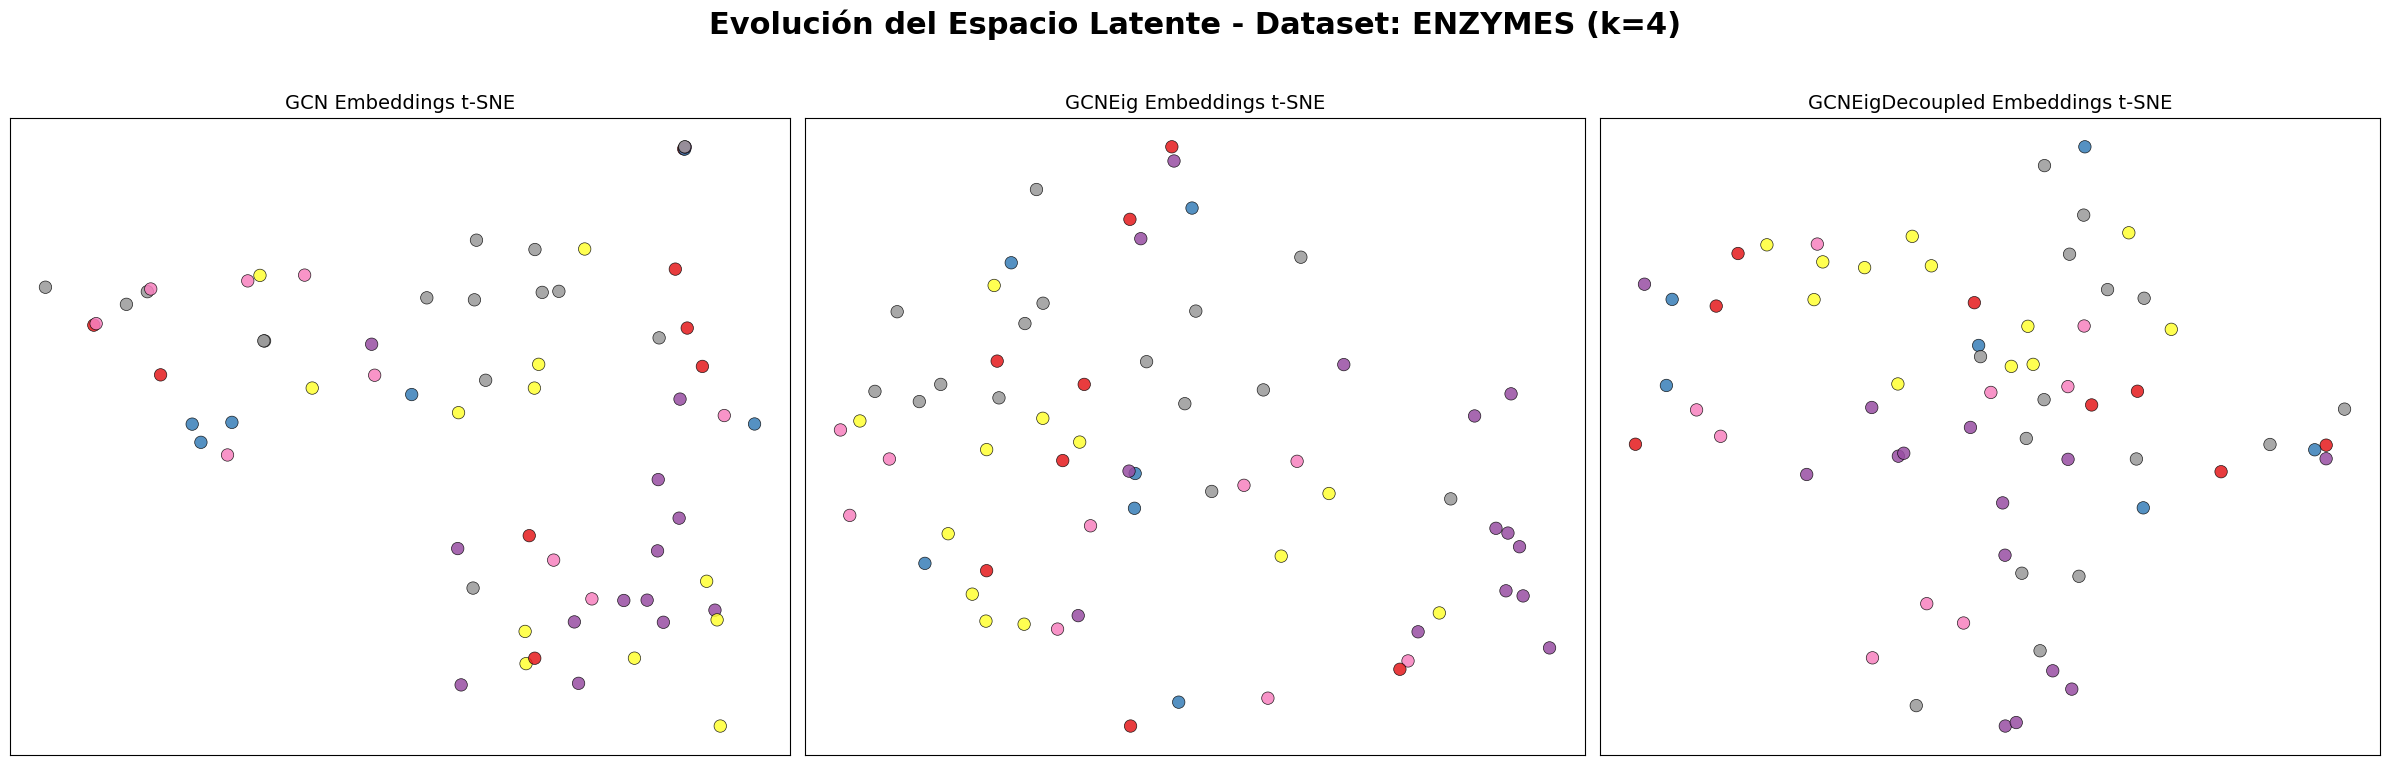

In [ ]:
# Get a fresh batch from test_loader for consistent visualization
data_for_viz = next(iter(test_loader)).to(device)

# GCN Model (global_best_models[0][0])
best_gcn_model = global_best_models[0][0]
out_gcn_embeddings = best_gcn_model.get_embeddings(data_for_viz.x, data_for_viz.edge_index, data_for_viz.batch)

evecs_list = []
for single_graph in data_for_viz.to_data_list():
    evecs_single = compute_laplacian_eigenvectors_pytorch(single_graph, k=k_val)
    evecs_list.append(evecs_single)

evecs_for_eig = torch.cat(evecs_list, dim=0).to(device)

x_for_eig = torch.cat([data_for_viz.x, evecs_for_eig], dim=1)

# GCNEig Model (global_best_models[1][0])
best_gcn_eig_model = global_best_models[1][0]
out_gcn_eig_embeddings = best_gcn_eig_model.get_embeddings(x_for_eig, data_for_viz.edge_index, data_for_viz.batch)

# GCNEigDecoupled Model (global_best_models[2][0])
best_gcn_eig_decoupled_model = global_best_models[2][0]
out_gcn_eig_decoupled_embeddings = best_gcn_eig_decoupled_model.get_embeddings(x_for_eig, data_for_viz.edge_index, data_for_viz.batch)


# TSNE Transformation
tsne = TSNE(n_components=2, random_state=12345, init='pca', learning_rate='auto')

tsne_gcn = tsne.fit_transform(out_gcn_embeddings.detach().cpu().numpy())
tsne_gcn_eig = tsne.fit_transform(out_gcn_eig_embeddings.detach().cpu().numpy())
tsne_gcn_decoupled = tsne.fit_transform(out_gcn_eig_decoupled_embeddings.detach().cpu().numpy())

fig, axs = plt.subplots(1, 3, figsize=(24, 8))

# GCN
axs[0].set_title('GCN Embeddings t-SNE', fontsize=14)
scatter0 = axs[0].scatter(tsne_gcn[:,0], tsne_gcn[:,1], c=data_for_viz.y.cpu(), cmap='Set1', s=80, alpha=0.85, edgecolors='black', linewidths=0.5)

# GCNEig
axs[1].set_title('GCNEig Embeddings t-SNE', fontsize=14)
axs[1].scatter(tsne_gcn_eig[:,0], tsne_gcn_eig[:,1], c=data_for_viz.y.cpu(), cmap='Set1', s=80, alpha=0.85, edgecolors='black', linewidths=0.5)

# GCNEigDecoupled
axs[2].set_title('GCNEigDecoupled Embeddings t-SNE', fontsize=14)
axs[2].scatter(tsne_gcn_decoupled[:,0], tsne_gcn_decoupled[:,1], c=data_for_viz.y.cpu(), cmap='Set1', s=80, alpha=0.85, edgecolors='black', linewidths=0.5)

for ax in axs:
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f'Evolución del Espacio Latente - Dataset: ENZYMES (k={k_val})', fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.show()

Al tratarse de un problema complejo de 6 clases, es esperable no encontrar una separación perfecta. No obstante, la visualización aporta información:

* **`GCN` (Izquierda):** Muestra una nube de puntos altamente dispersa donde los colores (clases enzimáticas) están completamente mezclados. La carencia de coordenadas espaciales impide a la red detectar patrones consistentes, ilustrando por qué el modelo apenas supera el 26% en validación.
* **`GCNEig` (Centro):** Empieza a apreciarse una ligera estructuración espacial con pequeños acercamientos por colores, pero el solapamiento global sigue siendo alto. Es el reflejo visual de una fusión temprana fallida: forzar a la red a procesar características bioquímicas junto al ruido geométrico en la misma capa dificulta la creación de fronteras de decisión limpias.
* **`GCNEigDecoupled` (Derecha):** La representación más estructurada. Aunque persiste mezcla (acorde a su 31.07% de precisión), se aprecian micro-clústeres locales mucho más marcados. Añadir la información geométrica en una capa posterior (y con dimensionalidad reducida) permite al modelo clasificar mejor.

### Conclusión Final y Comparación con la Tesis

* En el conjunto ENZYMES el principal escollo es el sobreajuste. Integrar *positional encoding* y agregaciones focalizadas (`Max Pool`) es vital para aislar las regiones activas, pero exige un equilibrio muy delicado en la capacidad de la red para evitar la memorización.
* Nuestro mejor modelo (`GCNEigDecoupled`) se sitúa en un **31.07%**. Por su parte, la tesis de referencia reporta un **39.40% ± 2.80** utilizando una arquitectura GatedGCN combinada con codificadores posicionales profundos (DPE).
* Quedar a poco más de 8 puntos porcentuales de la arquitectura de la tesis es un resultado digno, pero evidencia que se sigue teniendo un amplio margen de mejora, justificando la necesidad de explorar arquitecturas más sofisticadas en trabajos futuros.